<a href="https://colab.research.google.com/github/sofiiamyshelova-prog/python_for_ds_tasks/blob/main/Copy_of_HW_2_4_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%B1%D1%83%D1%81%D1%82%D0%B8%D0%BD%D0%B3%D1%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any


def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [26]:
from google.colab import drive
drive.mount('/content/drive')

raw_df = pd.read_csv('/content/drive/MyDrive/ML/data/train.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
train_df, val_df = split_train_val(df=raw_df, target_col='Exited')

train_inputs, train_targets = separate_inputs_targets(df=train_df,
                                          input_cols=[ 'CreditScore',
                                                      'Geography',
                                                      'Gender',
                                                      'Age',
                                                      'Tenure',
                                                      'Balance',
                                                      'NumOfProducts',
                                                      'HasCrCard',
                                                      'IsActiveMember',
                                                      'EstimatedSalary'],
                                          target_col='Exited')

val_inputs, val_targets = separate_inputs_targets(df=val_df,
                                          input_cols=[ 'CreditScore',
                                                      'Geography',
                                                      'Gender',
                                                      'Age',
                                                      'Tenure',
                                                      'Balance',
                                                      'NumOfProducts',
                                                      'HasCrCard',
                                                      'IsActiveMember',
                                                      'EstimatedSalary'],
                                          target_col='Exited')

1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [28]:
cat_features = train_inputs.select_dtypes(include='object').columns
train_inputs[cat_features] = train_inputs[cat_features].astype('category')
val_inputs[cat_features] = val_inputs[cat_features].astype('category')


Index(['Geography', 'Gender'], dtype='object')

2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [30]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# Навчання моделі
xgb_clf = XGBClassifier(max_depth=3,
    n_estimators=10,
    enable_categorical=True,  # для категорійних ознак
    use_label_encoder=False,  # щоб уникнути попереджень, якщо використовуєте нові версії XGBoost
    missing=np.nan,  # явне вказування пропущених значень
    device='cuda'
)
xgb_clf.fit(train_inputs, train_targets)

# Передбачення ймовірностей
train_preds = xgb_clf.predict_proba(train_inputs)[:, 1]
val_preds = xgb_clf.predict_proba(val_inputs)[:, 1]

# AUROC
train_auc = roc_auc_score(train_targets, train_preds)
val_auc = roc_auc_score(val_targets, val_preds)

print(f"Train ROC AUC: {train_auc:.4f}")
print(f"Validation ROC AUC: {val_auc:.4f}")

Train ROC AUC: 0.9330
Validation ROC AUC: 0.9318


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:46:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


з деревами раніше було отримано 0.93310

А зараз трохи гірше

Train ROC AUC: 0.9330

Validation ROC AUC: 0.9318

Модель якісна.

3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [31]:
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.metrics import accuracy_score

In [37]:
def objective(params):
    clf = xgb.XGBClassifier(
    n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        gamma=params['gamma'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        enable_categorical=True,
        use_label_encoder=False,
        missing=np.nan,
        device='cuda',
        early_stopping_rounds=20
    )

    clf.fit(
        train_inputs,
        train_targets,
        eval_set=[(val_inputs, val_targets)],
        verbose=False)
    pred = clf.predict(val_inputs)
    auc = roc_auc_score(val_targets, pred)

    return {'loss': -auc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20, trials=trials)

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf = xgb.XGBClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    gamma=best['gamma'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    enable_categorical=True,
    use_label_encoder=False,
    missing=np.nan,
    device='cuda',
)

final_clf.fit(train_inputs, train_targets)
train_pred = final_clf.predict(train_inputs)
train_auc = roc_auc_score(train_targets, train_pred)
print("AUC на тренувальній вибірці: {:.4f}".format(train_auc))
final_pred = final_clf.predict(val_inputs)
final_auc = roc_auc_score(val_targets, final_pred)
print("AUC на валідаційній вибірці: {:.4f}".format(final_auc))

  0%|          | 0/20 [00:00<?, ?trial/s, best loss=?]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [05:16:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



  5%|▌         | 1/20 [00:00<00:11,  1.70trial/s, best loss: -0.8226970299746209]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [05:16:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



 10%|█         | 2/20 [00:01<00:17,  1.01trial/s, best loss: -0.8226970299746209]

...

 95%|█████████▌| 19/20 [00:10<00:00,  3.90trial/s, best loss: -0.823725907126689] 

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [05:16:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [05:16:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



100%|██████████| 20/20 [00:10<00:00,  1.96trial/s, best loss: -0.823725907126689]
Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.7653611396000204), 'gamma': np.float64(0.1337464475334505), 'learning_rate': np.float64(0.19036872491719653), 'max_depth': 4, 'min_child_weight': 9, 'n_estimators': 225, 'reg_alpha': np.float64(0.19670278651225237), 'reg_lambda': np.float64(0.37879278609419054), 'subsample': np.float64(0.5890346751531959)}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:16:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


AUC на ренувальній вибірці: 0.8608
AUC на валідаційній вибірці: 0.8200


AUC на ренувальній вибірці: 0.8608

AUC на валідаційній вибірці: 0.8200

Модель не стала кращою, крім того є ще й перенавчання.

4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [38]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

cat_feature_indexes = [
    train_inputs.columns.get_loc(col)
    for col in cat_features
]

model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    random_state=42
)

model.fit(
    train_inputs,
    train_targets,
    categorical_feature=cat_feature_indexes
)

train_pred = model.predict_proba(train_inputs)[:, 1]
val_pred = model.predict_proba(val_inputs)[:, 1]

train_auc = roc_auc_score(train_targets, train_pred)
val_auc = roc_auc_score(val_targets, val_pred)

print(f"Train ROC AUC: {train_auc:.4f}")
print(f"Validation ROC AUC: {val_auc:.4f}")

[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001421 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

Модель якісна і краща за попередню.
Є перенавчання

5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

In [41]:
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials


# Простір пошуку
space = {
    "n_estimators": hp.quniform("n_estimators", 100, 500, 50),
    "learning_rate": hp.uniform("learning_rate", 0.01, 0.2),
    "max_depth": hp.quniform("max_depth", 3, 10, 1),
    "num_leaves": hp.quniform("num_leaves", 20, 100, 5),
    "min_child_samples": hp.quniform("min_child_samples", 10, 100, 5),
    "subsample": hp.uniform("subsample", 0.6, 1.0),
    "colsample_bytree": hp.uniform("colsample_bytree", 0.6, 1.0)
}

def objective(params):

    model = lgb.LGBMClassifier(
        n_estimators=int(params["n_estimators"]),
        learning_rate=params["learning_rate"],
        max_depth=int(params["max_depth"]),
        num_leaves=int(params["num_leaves"]),
        min_child_samples=int(params["min_child_samples"]),
        subsample=params["subsample"],
        colsample_bytree=params["colsample_bytree"],
        random_state=42,
        verbosity=-1
    )

    model.fit(
        train_inputs,
        train_targets,
        categorical_feature=cat_feature_indexes
    )

    pred = model.predict_proba(val_inputs)[:, 1]

    auc = roc_auc_score(val_targets, pred)

    return {
        "loss": -auc,
        "status": STATUS_OK
    }

#пошук
trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=10,
    trials=trials
)

best["n_estimators"] = int(best["n_estimators"])
best["max_depth"] = int(best["max_depth"])
best["num_leaves"] = int(best["num_leaves"])
best["min_child_samples"] = int(best["min_child_samples"])

final_lgb_clf = lgb.LGBMClassifier(
    n_estimators=best["n_estimators"],
    learning_rate=best["learning_rate"],
    max_depth=best["max_depth"],
    num_leaves=best["num_leaves"],
    min_child_samples=best["min_child_samples"],
    subsample=best["subsample"],
    colsample_bytree=best["colsample_bytree"],
    random_state=42
)

final_lgb_clf.fit(
    train_inputs,
    train_targets,
    categorical_feature=cat_feature_indexes
)

train_pred = final_lgb_clf.predict_proba(train_inputs)[:, 1]
val_pred = final_lgb_clf.predict_proba(val_inputs)[:, 1]

train_auc = roc_auc_score(train_targets, train_pred)
val_auc = roc_auc_score(val_targets, val_pred)

print(f"Train ROC AUC: {train_auc:.4f}")
print(f"Validation ROC AUC: {val_auc:.4f}")

100%|██████████| 10/10 [00:09<00:00,  1.05trial/s, best loss: -0.9369154262981001]
Train ROC AUC: 0.9426
Validation ROC AUC: 0.9369


Модель ще покращилась

6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

In [48]:
test = pd.read_csv('/content/drive/MyDrive/ML/data/test.csv')

test_inputs = test[[ 'CreditScore',
                                                      'Geography',
                                                      'Gender',
                                                      'Age',
                                                      'Tenure',
                                                      'Balance',
                                                      'NumOfProducts',
                                                      'HasCrCard',
                                                      'IsActiveMember',
                                                      'EstimatedSalary']].copy()
test_inputs[cat_features] = test_inputs[cat_features].astype('category')

#обираю останню оптимізовану модель, бо вона показала найкращий результат за roc auc
test_probs = final_lgb_clf.predict_proba(test_inputs)[:, 1]

sample_submission = pd.read_csv('/content/drive/MyDrive/ML/data/sample_submission.csv')
sample_submission["Exited"] = test_probs
print(sample_submission.head())

sample_submission.to_csv("submission.csv", index=False)


      id    Exited
0  15000  0.139069
1  15001  0.021728
2  15002  0.063034
3  15003  0.567538
4  15004  0.039759


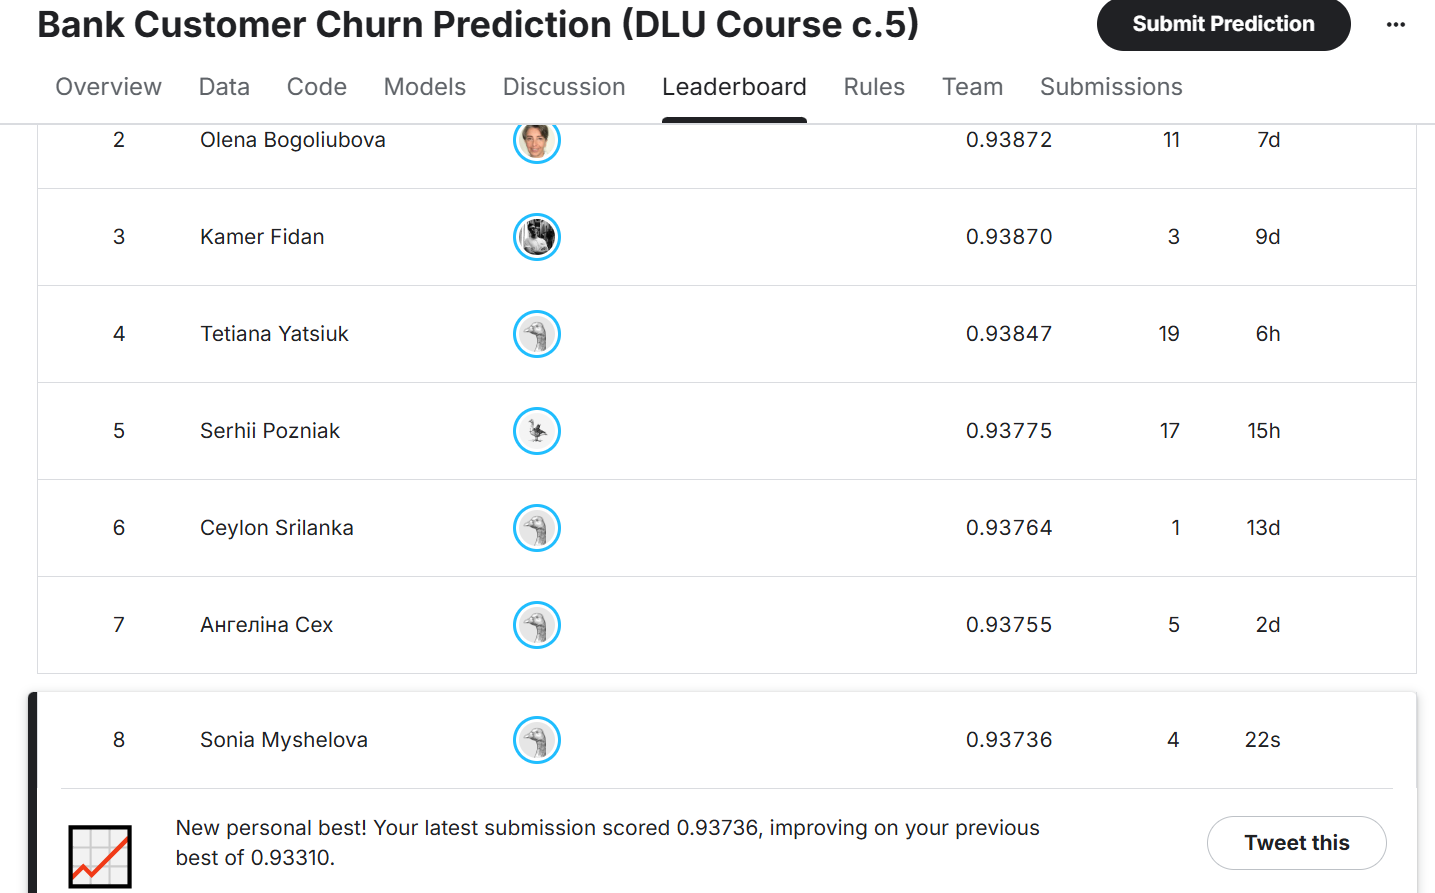